<a href="https://colab.research.google.com/github/anex4real/Assignment-1/blob/main/Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_17910/1073232553.py:28: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10(signal_power / noise_power)


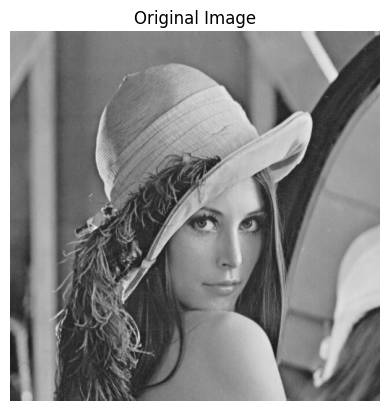

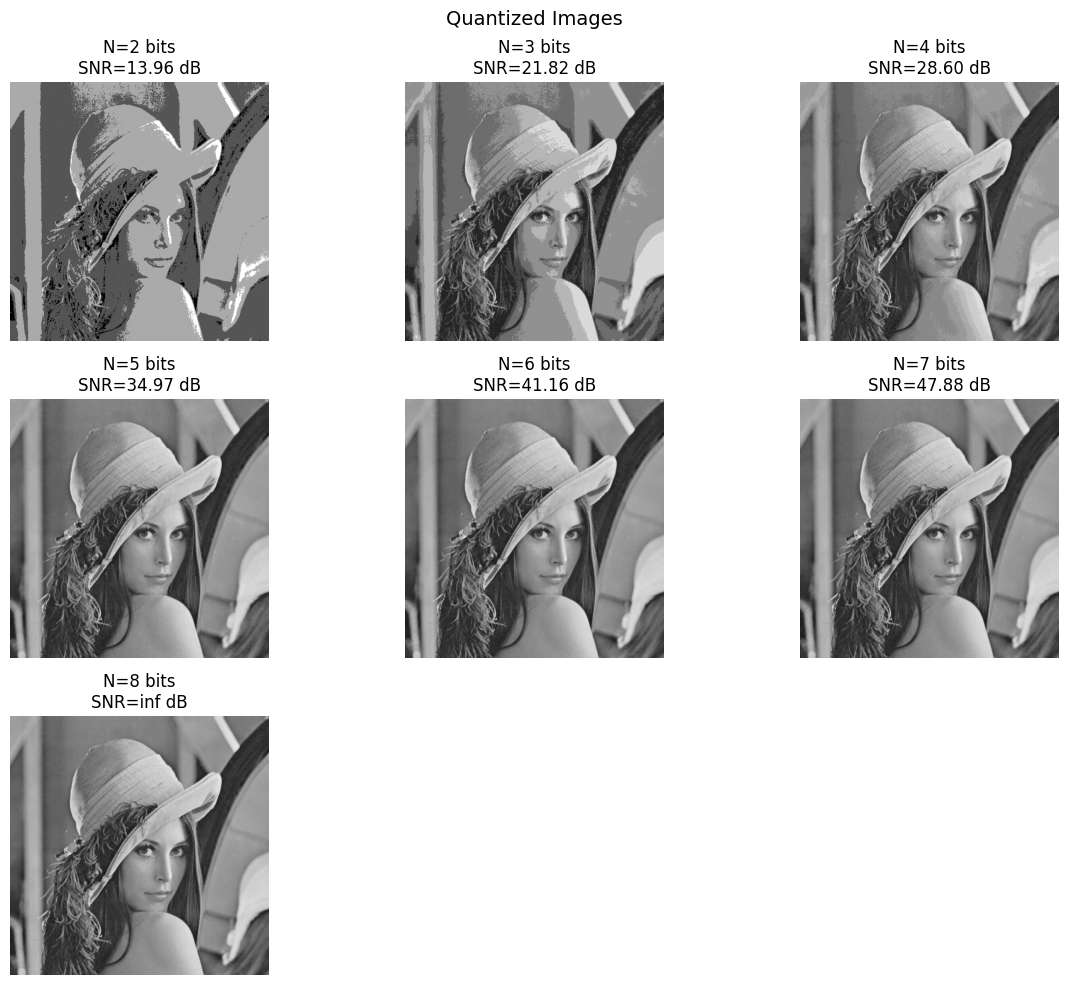

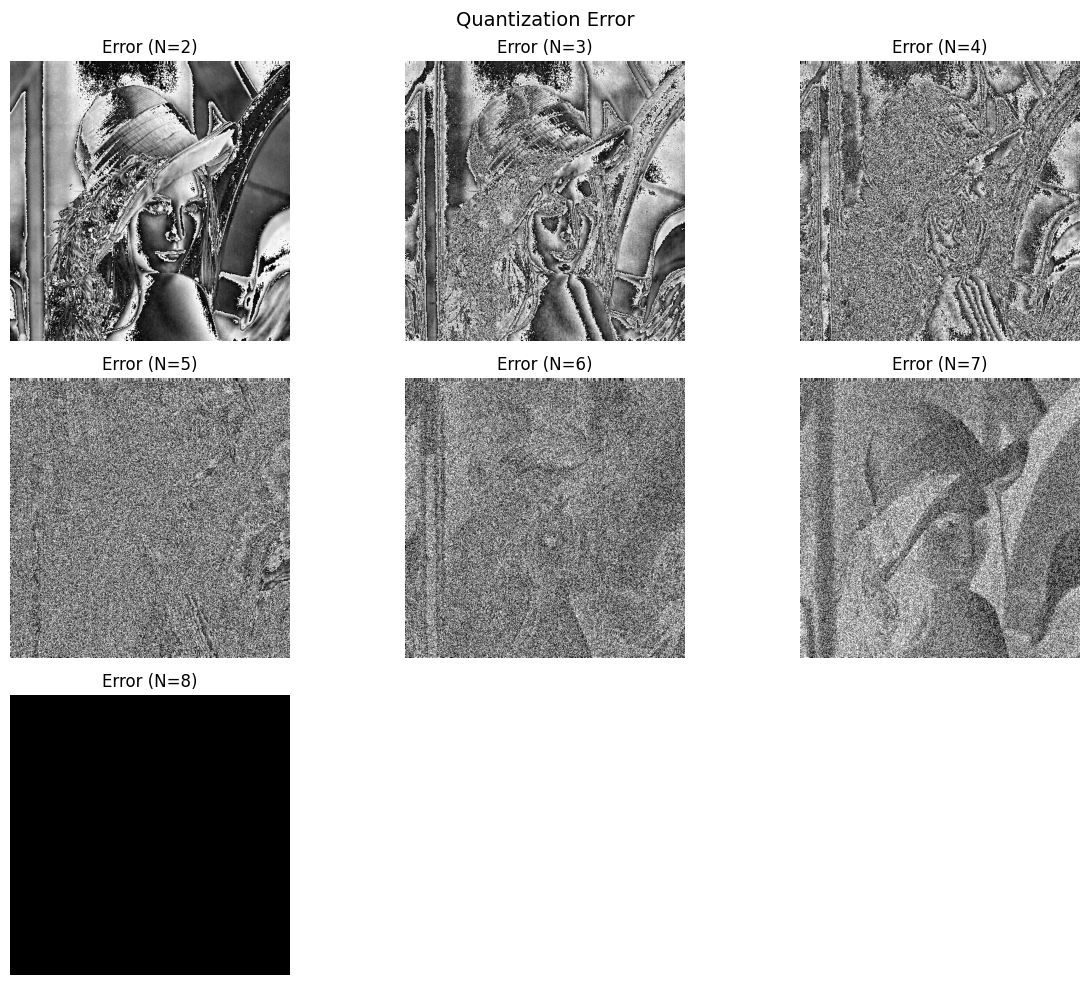

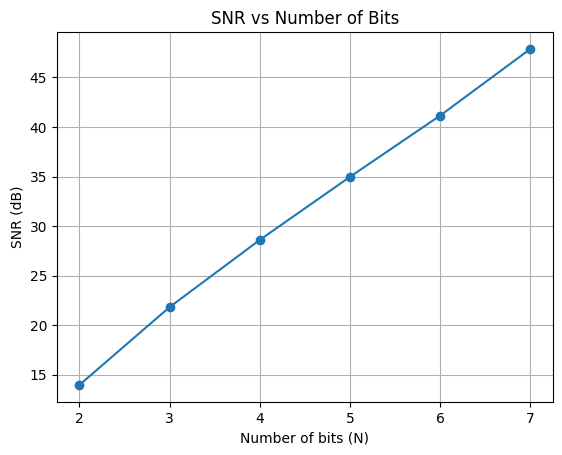

SNR ≈ nan * N + nan


In [2]:
# ===== FULL IMAGE QUANTIZATION PIPELINE (Q3 + Q4 SUPPORT) =====

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ---- Load image ----
img = Image.open('lena512.bmp').convert('L')  # grayscale
A = np.array(img, dtype=np.float32)

# Display original image
plt.figure()
plt.imshow(A, cmap='gray', vmin=0, vmax=255)
plt.title('Original Image')
plt.axis('off')

# Normalize to [0,1]
A = A / 255.0

# ---- Functions ----
def quantize_image(image, N):
    L = 2**N
    return np.round(image * (L - 1)) / (L - 1)

def compute_snr(original, reconstructed):
    signal_power = np.mean(original**2)
    noise_power = np.mean((original - reconstructed)**2)
    return 10 * np.log10(signal_power / noise_power)

# ---- Main processing ----
N_values = [2, 3, 4, 5, 6, 7, 8]
snr_values = []

# Quantized images
plt.figure(figsize=(12, 10))
for i, N in enumerate(N_values):
    Aq = quantize_image(A, N)
    snr = compute_snr(A, Aq)
    snr_values.append(snr)

    Aq_display = (Aq * 255).astype(np.uint8)

    plt.subplot(3, 3, i+1)
    plt.imshow(Aq_display, cmap='gray', vmin=0, vmax=255)
    plt.title(f'N={N} bits\nSNR={snr:.2f} dB')
    plt.axis('off')

plt.suptitle('Quantized Images', fontsize=14)
plt.tight_layout()
plt.show()

# ---- Error images ----
plt.figure(figsize=(12, 10))
for i, N in enumerate(N_values):
    Aq = quantize_image(A, N)
    error = A - Aq

    plt.subplot(3, 3, i+1)
    plt.imshow(error, cmap='gray')
    plt.title(f'Error (N={N})')
    plt.axis('off')

plt.suptitle('Quantization Error', fontsize=14)
plt.tight_layout()
plt.show()

# ---- SNR vs Bits ----
plt.figure()
plt.plot(N_values, snr_values, marker='o')
plt.xlabel('Number of bits (N)')
plt.ylabel('SNR (dB)')
plt.title('SNR vs Number of Bits')
plt.grid()
plt.show()

# ---- Linear model (polyfit) ----
a, b = np.polyfit(N_values, snr_values, 1)
print(f"SNR ≈ {a:.2f} * N + {b:.2f}")